In [1]:
import os
import glob
import random
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision  
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import time
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # GAN en CPU es muy lento; usa GPU si tienes
torch.manual_seed(0)
random.seed(0)
EXTENSIONES_VALIDAS = [".pgm", ".png", ".jpg", ".jpeg", ".bmp"]
DATASET_PATH = Path("../dataset")
CLEAN_DIR = DATASET_PATH / "ORL_Limpio"
DEGRADACION_DIR = DATASET_PATH / "Degradacion"
SCALE = 2 
IMG_SIZE = (112, 92)  
DEGRADED_DIR = DEGRADACION_DIR / f"ORL_escala{SCALE}"
print(device)

cuda


In [2]:
class SRResidualBlock(nn.Module):
    def __init__(self, num_channel=64, num_channel_grow=16):
        super(SRResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(num_channel, num_channel_grow, 3, 1, 1)
        self.conv2 = nn.Conv2d(num_channel + num_channel_grow * 1, num_channel_grow, 3, 1, 1)
        self.conv3 = nn.Conv2d(num_channel + num_channel_grow * 2, num_channel_grow, 3, 1, 1)
        self.conv4 = nn.Conv2d(num_channel + num_channel_grow * 3, num_channel_grow, 3, 1, 1)
        self.conv5 = nn.Conv2d(num_channel + num_channel_grow * 4, num_channel, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(0.1, inplace=True)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat((x, x1), 1)))
        x3 = self.lrelu(self.conv3(torch.cat((x, x1, x2), 1)))
        x4 = self.lrelu(self.conv4(torch.cat((x, x1, x2, x3), 1)))
        x5 = self.conv5(torch.cat((x, x1, x2, x3, x4), 1))
        return x + x5 * 0.2


class SRNet(nn.Module):
    def __init__(self, num_residual_block=6, in_channels=1, out_channels=1):
        super(SRNet, self).__init__()
        self.conv_first = nn.Conv2d(in_channels, 64, 3, 1, 1)
        self.conv_body = nn.Sequential(*[SRResidualBlock() for _ in range(num_residual_block)])
        self.conv_after_body = nn.Conv2d(64, 64, 3, 1, 1)
        self.conv_up1 = nn.Sequential(
            nn.Conv2d(64, 32, 3, 1, 1),
            nn.LeakyReLU(0.1, True),
        )
        self.conv_end = nn.Sequential(
            nn.Conv2d(32, 16, 3, 1, 1),
            nn.LeakyReLU(0.1, True),
            nn.Conv2d(16, out_channels, 3, 1, 1),
        )
        self.lrelu = nn.LeakyReLU(0.1, inplace=True)

    def forward(self, x):
        out_first = self.conv_first(x)
        out = self.conv_body(out_first)
        out = self.conv_after_body(out + out_first)
        out = self.conv_up1(out)
        out = self.conv_end(out)
        # Conexion residual global: la red solo aprende la CORRECCION
        # de la imagen degradada, no la imagen completa desde cero.
        # Ademas se limita la salida al rango valido [0,1] para no
        # desplazar el brillo/contraste.
        return torch.clamp(x + out, 0.0, 1.0)


def count_parameters(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

In [3]:
class Discriminator(nn.Module):
    def __init__(self, in_channels=1):
        super(Discriminator, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 4, 2, 1),
            nn.InstanceNorm2d(32),
            nn.LeakyReLU(0.1, True),

            nn.Conv2d(32, 64, 4, 2, 1),
            nn.InstanceNorm2d(64),
            nn.LeakyReLU(0.1, True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.1, True),

            nn.Conv2d(128, 128, 4, 2, 1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.1, True),

            nn.Conv2d(128, 128, 4, 2, 1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.1, True),

            nn.Conv2d(128, 1, 4, 2, 1),
        )

    def forward(self, x):
        return self.conv(x)

In [4]:
import torchvision
import torch
import torch.nn as nn

class ShuffleNetPerceptualLoss(nn.Module):
    def __init__(self, layer_ids=(1, 3, 7, 15)):
        super().__init__()

        # Modelo preentrenado
        shufflenet = torchvision.models.shufflenet_v2_x0_5(
            weights=torchvision.models.ShuffleNet_V2_X0_5_Weights.DEFAULT
        )

        self.features = shufflenet.conv1
        self.maxpool = shufflenet.maxpool

        self.stage2 = shufflenet.stage2
        self.stage3 = shufflenet.stage3
        self.stage4 = shufflenet.stage4
        self.conv5 = shufflenet.conv5

        # Congelar pesos
        for p in shufflenet.parameters():
            p.requires_grad = False

        self.criterion = nn.L1Loss()

        self.register_buffer(
            "mean",
            torch.tensor([0.485,0.456,0.406]).view(1,3,1,1)
        )

        self.register_buffer(
            "std",
            torch.tensor([0.229,0.224,0.225]).view(1,3,1,1)
        )

    def preprocess(self,x):

        if x.size(1)==1:
            x=x.repeat(1,3,1,1)

        return (x-self.mean)/self.std

    def extract(self,x):

        feats=[]

        x=self.features(x)
        feats.append(x)

        x=self.maxpool(x)

        x=self.stage2(x)
        feats.append(x)

        x=self.stage3(x)
        feats.append(x)

        x=self.stage4(x)
        feats.append(x)

        return feats

    def forward(self,sr,hr):

        sr=self.preprocess(sr)
        hr=self.preprocess(hr)

        sr_feats=self.extract(sr)

        with torch.no_grad():
            hr_feats=self.extract(hr)

        loss=0

        for f1,f2 in zip(sr_feats,hr_feats):
            loss+=self.criterion(f1,f2)

        return loss/len(sr_feats)

In [5]:
def train_stage2(generator, discriminator, train_loader, val_loader, device,
                  epochs=50, lr_g=1e-4, lr_d=1e-4,
                  w_pixel=1.0, w_perceptual=1.0, w_adv=0.05,
                  checkpoint_path="srnet_stage2.pth",
                  print_every=1,
                  scale=None,
                  perceptual_every=4,
                  d_update_every=2,       # <-- NUEVO: entrena D solo 1 de cada N batches
                  label_smoothing=0.9,    # <-- NUEVO: etiquetas reales suavizadas (evita D sobreconfiado)
                  adv_warmup_epochs=0):   # <-- NUEVO: nº de epocas iniciales con w_adv=0

    generator.to(device)
    discriminator.to(device)
    perceptual_loss_fn = ShuffleNetPerceptualLoss().to(device)

    l1 = nn.L1Loss()
    bce = nn.BCEWithLogitsLoss()

    opt_g = torch.optim.Adam(generator.parameters(), lr=lr_g, betas=(0.9, 0.99))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr_d, betas=(0.9, 0.99))

    best_val_loss = float("inf")
    t_start = time.time()

    for epoch in range(1, epochs + 1):

        t_epoch = time.time()

        # =========================
        # Entrenamiento
        # =========================
        generator.train()
        discriminator.train()

        g_loss_acc = 0.0
        d_loss_acc = 0.0

        pix_acc = 0.0
        perc_acc = 0.0
        adv_acc = 0.0

        n = 0

        # ---------- CAMBIO ----------
        for batch_idx, (lr_img, hr_img) in enumerate(
                tqdm(train_loader,
                     desc=f"Época {epoch} [train]",
                     leave=False)):

            lr_img = lr_img.to(device)
            hr_img = hr_img.to(device)

            b = lr_img.size(0)

            # =========================
            # Discriminador
            # =========================

            sr_img = generator(lr_img)

            # Entrenar el discriminador solo 1 de cada d_update_every batches,
            # para que no se vuelva demasiado fuerte demasiado rápido
            # (evita que D colapse a ~0 y sature el gradiente adversarial).
            if batch_idx % d_update_every == 0:

                opt_d.zero_grad()

                pred_real = discriminator(hr_img)
                pred_fake = discriminator(sr_img.detach())

                # Label smoothing: las etiquetas "reales" no son 1.0 sino
                # label_smoothing (p.ej. 0.9), para que D nunca esté 100%
                # seguro y no sature el gradiente que recibe el generador.
                real_labels = torch.ones_like(pred_real) * label_smoothing
                fake_labels = torch.zeros_like(pred_fake)

                loss_d = (
                    bce(pred_real, real_labels)
                    +
                    bce(pred_fake, fake_labels)
                )

                loss_d.backward()
                opt_d.step()
            else:
                loss_d = torch.tensor(0.0, device=device)

            # =========================
            # Generador
            # =========================

            opt_g.zero_grad()

            pred_fake_for_g = discriminator(sr_img)

            loss_pixel = l1(sr_img, hr_img)

            # =====================================================
            # NUEVA OPTIMIZACIÓN
            # =====================================================

            if batch_idx % perceptual_every == 0:

                loss_perceptual = perceptual_loss_fn(
                    sr_img,
                    hr_img
                )

            else:

                loss_perceptual = torch.tensor(
                    0.0,
                    device=device,
                    dtype=loss_pixel.dtype
                )

            loss_adv = bce(
                pred_fake_for_g,
                torch.ones_like(pred_fake_for_g)
            )

            # Warm-up: durante las primeras adv_warmup_epochs épocas no se
            # aplica el término adversarial, para que el generador aprenda
            # primero una buena estructura antes de que el GAN empiece a
            # empujarlo (evita que distorsione geometría desde el inicio).
            w_adv_effective = 0.0 if epoch <= adv_warmup_epochs else w_adv

            loss_g = (
                w_pixel * loss_pixel
                +
                w_perceptual * loss_perceptual
                +
                w_adv_effective * loss_adv
            )

            loss_g.backward()
            opt_g.step()

            # =========================
            # Estadísticas
            # =========================

            g_loss_acc += loss_g.item() * b
            d_loss_acc += loss_d.item() * b

            pix_acc += loss_pixel.item() * b
            perc_acc += loss_perceptual.item() * b
            adv_acc += loss_adv.item() * b

            n += b

        g_loss_acc /= n
        d_loss_acc /= n

        pix_acc /= n
        perc_acc /= n
        adv_acc /= n

        # =========================
        # Validación
        # =========================

        generator.eval()

        val_loss = 0.0
        n_val = 0

        with torch.no_grad():

            for lr_img, hr_img in val_loader:

                lr_img = lr_img.to(device)
                hr_img = hr_img.to(device)

                sr_img = generator(lr_img)

                val_loss += l1(sr_img, hr_img).item() * lr_img.size(0)
                n_val += lr_img.size(0)

        val_loss /= n_val

        elapsed = time.time() - t_epoch

        guardado = ""

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            torch.save({
                "generator_state_dict": generator.state_dict(),
                "discriminator_state_dict": discriminator.state_dict(),
                "epoch": epoch,
                "val_loss": val_loss,
                "scale": scale,
            }, checkpoint_path)

            guardado = "  ✦ guardado"

        if epoch == 1 or epoch % print_every == 0:

            current_lr_g = opt_g.param_groups[0]["lr"]

            print(
                f"Época [{epoch:3d}/{epochs}]  "
                f"G: {g_loss_acc:.4f} "
                f"(pix={pix_acc:.4f} "
                f"perc={perc_acc:.4f} "
                f"adv={adv_acc:.4f})  "
                f"D: {d_loss_acc:.4f}  "
                f"val_L1: {val_loss:.6f}  "
                f"lr_g: {current_lr_g:.2e}  "
                f"t: {elapsed:.0f}s{guardado}"
            )

    total_elapsed = time.time() - t_start

    print("─" * 64)
    print(f"Entrenamiento completado en {total_elapsed:.1f} s")
    print(f"Mejor val loss: {best_val_loss:.6f} → {Path(checkpoint_path).name}")

    return checkpoint_path

In [6]:
def _buscar_por_stem(carpeta: Path, stem: str):
    for ext in EXTENSIONES_VALIDAS:
        candidato = carpeta / f"{stem}{ext}"
        if candidato.is_file():
            return candidato
    return None


def list_pairs(clean_split_dir: Path, degraded_split_dir: Path):
    pairs = []
    subject_dirs = sorted(d for d in clean_split_dir.glob("s*") if d.is_dir())
    for clean_subj_dir in subject_dirs:
        subject_name = clean_subj_dir.name
        degraded_subj_dir = degraded_split_dir / subject_name
        assert degraded_subj_dir.is_dir(), f"Falta carpeta degradada: {degraded_subj_dir}"
        clean_files = sorted(f for f in clean_subj_dir.glob("*.*") if f.suffix.lower() in EXTENSIONES_VALIDAS)
        for clean_path in clean_files:
            degraded_path = _buscar_por_stem(degraded_subj_dir, clean_path.stem)
            assert degraded_path is not None, f"Falta par degradado para: {clean_path.name} en {degraded_subj_dir}"
            pairs.append((degraded_path, clean_path))
    return pairs


class PairedGraySRDataset(Dataset):
    def __init__(self, pairs, img_size=(112, 92)):
        self.pairs = pairs
        self.h, self.w = img_size
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        lr_path, hr_path = self.pairs[idx]
        hr = Image.open(hr_path).convert('L')
        lr = Image.open(lr_path).convert('L')
        target_size = (self.w, self.h)
        if hr.size != target_size:
            hr = hr.resize(target_size, Image.BICUBIC)
        if lr.size != target_size:
            lr = lr.resize(target_size, Image.BICUBIC)
        return self.to_tensor(lr), self.to_tensor(hr)


train_pairs = list_pairs(CLEAN_DIR / "Training", DEGRADED_DIR / "Training")
test_pairs = list_pairs(CLEAN_DIR / "Testing", DEGRADED_DIR / "Testing")

train_ds = PairedGraySRDataset(train_pairs, img_size=IMG_SIZE)
val_ds = PairedGraySRDataset(test_pairs, img_size=IMG_SIZE)

print(f"[Escala x{SCALE}] Training pairs: {len(train_ds)}  (esperado 360)")
print(f"[Escala x{SCALE}] Testing pairs:  {len(val_ds)}  (esperado 40)")

[Escala x2] Training pairs: 360  (esperado 360)
[Escala x2] Testing pairs:  40  (esperado 40)


In [7]:
BATCH_SIZE = 16
EPOCHS = 15

LR_G = 1e-4
LR_D = 3e-5   # antes 1e-4: D aprendía mas rapido que G y colapsaba (D->~0, adv se disparaba)

W_PIXEL = 1.0
W_PERCEPTUAL = 0.3   # antes 1.0: dominaba demasiado sobre L1 para rostros pequenos
W_ADV = 0.01         # antes 0.05: adv~8.5 * 0.05 ~= 0.42, opacaba a pixel (~0.06)
PERCEPTUAL_EVERY = 4

PRINT_EVERY = 1
CHECKPOINT_PATH = Path("../model_lite") / f"srnet_stage2_escala{SCALE}_best.pth"
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

generator = SRNet(
    num_residual_block=8,     
    in_channels=1,
    out_channels=1
).to(device)

discriminator = Discriminator(
    in_channels=1
).to(device)

print(f"Parámetros generador: {count_parameters(generator):,}")
print(f"Parámetros discriminador: {count_parameters(discriminator):,}")

print("Iniciando entrenamiento (Stage 2, MobileNetV2 perceptual)...")
print(f"   Escala            : x{SCALE}")
print(f"   Épocas            : {EPOCHS}")
print(f"   Batch             : {BATCH_SIZE}")
print(f"   LR G/D            : {LR_G} / {LR_D}")
print(f"   Pesos             : pixel={W_PIXEL}  perceptual={W_PERCEPTUAL}  adv={W_ADV}")
print(f"   Perceptual cada   : {PERCEPTUAL_EVERY} batches")
print("─" * 64)

CHECKPOINT_PATH = train_stage2(
    generator=generator,
    discriminator=discriminator,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=EPOCHS,
    lr_g=LR_G,
    lr_d=LR_D,
    w_pixel=W_PIXEL,
    w_perceptual=W_PERCEPTUAL,
    w_adv=W_ADV,
    checkpoint_path=str(CHECKPOINT_PATH),
    print_every=PRINT_EVERY,
    scale=SCALE,
    perceptual_every=PERCEPTUAL_EVERY,
    d_update_every=2,       # D se actualiza cada 2 batches, no en todos
    label_smoothing=0.9,    # etiquetas reales suavizadas
    adv_warmup_epochs=10,   # primeras 10 epocas sin GAN, solo pixel+perceptual
)

Parámetros generador: 1,057,153
Parámetros discriminador: 691,169
Iniciando entrenamiento (Stage 2, MobileNetV2 perceptual)...
   Escala            : x2
   Épocas            : 15
   Batch             : 16
   LR G/D            : 0.0001 / 3e-05
   Pesos             : pixel=1.0  perceptual=0.3  adv=0.01
   Perceptual cada   : 4 batches
────────────────────────────────────────────────────────────────


Época [  1/15]  G: 0.0835 (pix=0.0707 perc=0.0427 adv=0.7828)  D: 0.6950  val_L1: 0.065285  lr_g: 1.00e-04  t: 9s  ✦ guardado


Época [  2/15]  G: 0.0763 (pix=0.0635 perc=0.0427 adv=0.8669)  D: 0.6386  val_L1: 0.060348  lr_g: 1.00e-04  t: 8s  ✦ guardado


Época [  3/15]  G: 0.0734 (pix=0.0607 perc=0.0422 adv=0.9853)  D: 0.5971  val_L1: 0.059178  lr_g: 1.00e-04  t: 8s  ✦ guardado


Época [  4/15]  G: 0.0722 (pix=0.0595 perc=0.0426 adv=1.0560)  D: 0.5532  val_L1: 0.057206  lr_g: 1.00e-04  t: 8s  ✦ guardado


...

Época [ 11/15]  G: 0.0789 (pix=0.0527 perc=0.0393 adv=1.4323)  D: 0.4043  val_L1: 0.055208  lr_g: 1.00e-04  t: 8s


Época [ 12/15]  G: 0.0795 (pix=0.0534 perc=0.0401 adv=1.4158)  D: 0.4234  val_L1: 0.050341  lr_g: 1.00e-04  t: 8s  ✦ guardado


Época [ 13/15]  G: 0.0795 (pix=0.0530 perc=0.0398 adv=1.4528)  D: 0.4010  val_L1: 0.051344  lr_g: 1.00e-04  t: 8s


Época [ 14/15]  G: 0.0809 (pix=0.0535 perc=0.0397 adv=1.5528)  D: 0.3706  val_L1: 0.052385  lr_g: 1.00e-04  t: 8s


Época [ 15/15]  G: 0.0810 (pix=0.0527 perc=0.0400 adv=1.6272)  D: 0.3622  val_L1: 0.051895  lr_g: 1.00e-04  t: 8s
────────────────────────────────────────────────────────────────
Entrenamiento completado en 123.1 s
Mejor val loss: 0.050341 → srnet_stage2_escala2_best.pth


Pesos cargados desde época 12  (val_loss=0.050341)


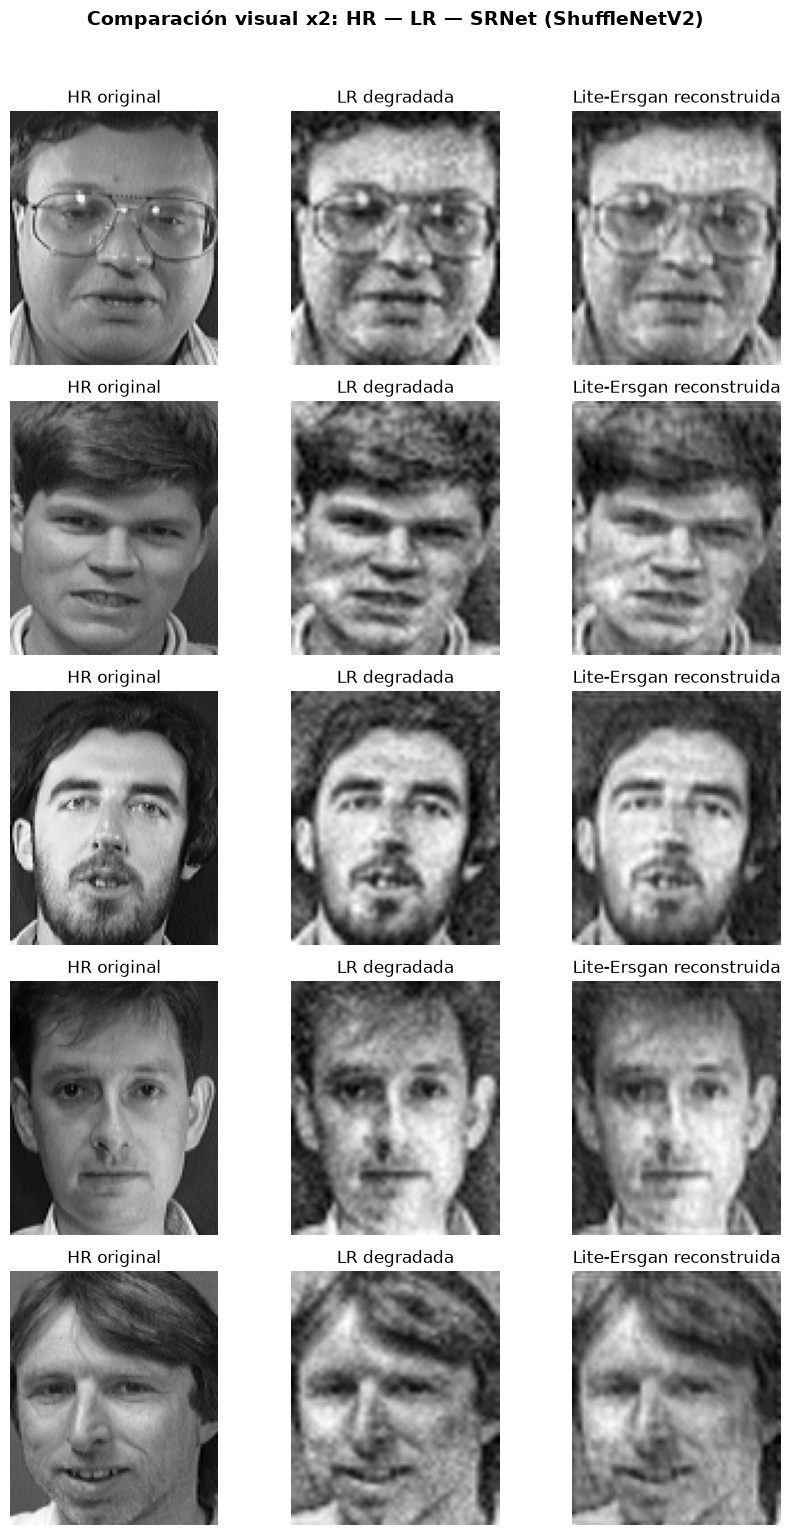

In [8]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
generator.load_state_dict(checkpoint['generator_state_dict'])  # [FIX 3] antes: 'model_state_dict'
generator.eval()
print(f"Pesos cargados desde época {checkpoint['epoch']}  (val_loss={checkpoint['val_loss']:.6f})")


def tensor_to_np(t):
    return t.squeeze().detach().cpu().numpy()


def mostrar_comparacion(n_examples=5, cmap='gray'):
    fig, axes = plt.subplots(n_examples, 3, figsize=(9, 3 * n_examples))
    fig.suptitle(f"Comparación visual x{SCALE}: HR — LR — SRNet (ShuffleNetV2)", fontsize=14, fontweight='bold', y=1.02)
    indices = random.sample(range(len(val_ds)), n_examples)
    with torch.no_grad():
        for row, idx in enumerate(indices):
            lr_img, hr_img = val_ds[idx]
            pred = generator(lr_img.unsqueeze(0).to(device))
            axes[row, 0].imshow(tensor_to_np(hr_img), cmap=cmap)
            axes[row, 0].set_title("HR original")
            axes[row, 1].imshow(tensor_to_np(lr_img), cmap=cmap, interpolation='bilinear')
            axes[row, 1].set_title("LR degradada")
            axes[row, 2].imshow(tensor_to_np(pred), cmap=cmap)
            axes[row, 2].set_title("Lite-Ersgan reconstruida")
            for ax in axes[row]:
                ax.axis('off')
    plt.tight_layout()
    plt.show()


mostrar_comparacion(n_examples=5)